In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Load the new dataset
df = pd.read_csv("/content/drive/MyDrive/diabetes_data_pre_processed.csv")

# Define Target and Features to be used
target_variable = 'diabetes'
# Selecting all original features and the newly created one-hot encoded columns
features = ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
            'bmi', 'HbA1c_level', 'blood_glucose_level',
            'age_group_Adult', 'age_group_Middle-aged', 'age_group_Senior', 'age_group_Young']

X = df[features]
y = df[target_variable]

# --- Validation Method 1: Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create the preprocessing ColumnTransformer
# Since all features are now numerical/binary, we apply StandardScaler to all of them.
preprocessor = ColumnTransformer(
    transformers=[
        ('all_features', StandardScaler(), X_train.columns)
    ],
    remainder='drop'
)

print("Setup Complete: Data split and SIMPLIFIED Preprocessing Pipeline (StandardScaler on all features) defined.")
print(f"Training set size: {X_train.shape[0]}, Testing set size: {X_test.shape[0]}")

Setup Complete: Data split and SIMPLIFIED Preprocessing Pipeline (StandardScaler on all features) defined.
Training set size: 137427, Testing set size: 34357


Model Variety 1 (Baseline Logistic Regression)

In [2]:
# --- Model Variety 1: Baseline Logistic Regression Pipeline ---

# Create the full pipeline: Preprocessor + Classifier
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    # Default Logistic Regression model (C=1.0)
    ('classifier', LogisticRegression(random_state=42, solver='liblinear'))
])

# Train the Baseline Model
print("\nTraining Model Variety 1: Baseline Logistic Regression...")
baseline_pipeline.fit(X_train, y_train)

# Predict and get probabilities for evaluation
y_pred_baseline = baseline_pipeline.predict(X_test)
y_prob_baseline = baseline_pipeline.predict_proba(X_test)[:, 1]

print("Model Variety 1 Trained.")


Training Model Variety 1: Baseline Logistic Regression...
Model Variety 1 Trained.


Model Variety 2 (Tuned Logistic Regression with GridSearchCV)

In [3]:
# --- Model Variety 2: Tuned Logistic Regression with GridSearchCV ---

# Parameter Tuning Method: GridSearchCV
# Define the parameter grid to tune the 'C' regularization strength
param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l2']
}

# Create the Grid Search object (5-fold cross-validation)
grid_search = GridSearchCV(
    baseline_pipeline,
    param_grid,
    cv=5,
    scoring='f1',       # Optimizing for F1 Score
    n_jobs=-1
)

# Perform the Grid Search
print("\nTraining Model Variety 2: Tuned Logistic Regression (GridSearchCV)...")
grid_search.fit(X_train, y_train)

# Get the best model and its parameters
tuned_pipeline = grid_search.best_estimator_
best_params = grid_search.best_params_

# Predict and get probabilities using the Tuned Model
y_pred_tuned = tuned_pipeline.predict(X_test)
y_prob_tuned = tuned_pipeline.predict_proba(X_test)[:, 1]

print("Model Variety 2 Trained.")
print(f"Best Parameters found: {best_params}")


Training Model Variety 2: Tuned Logistic Regression (GridSearchCV)...
Model Variety 2 Trained.
Best Parameters found: {'classifier__C': 0.001, 'classifier__penalty': 'l2'}


Evaluation and Comparison

In [4]:
# --- Evaluation Metrics and Comparison ---

def calculate_metrics(y_true, y_pred, y_prob, model_name):
    """Calculates all required classification metrics."""
    return pd.Series({
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall (Sensitivity)': recall_score(y_true, y_pred, zero_division=0),
        'F1 Score': f1_score(y_true, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_true, y_prob)
    })

# Evaluate both models on the test set
metrics_baseline = calculate_metrics(y_test, y_pred_baseline, y_prob_baseline, 'Baseline LR')
metrics_tuned = calculate_metrics(y_test, y_pred_tuned, y_prob_tuned, 'Tuned LR')

# Compile results for comparison
results_df = pd.DataFrame([metrics_baseline, metrics_tuned]).set_index('Model')

print("\n--- Model Evaluation Results (on Test Set) ---")
print("Metrics are crucial for medical prediction (Recall/F1 are prioritized over Accuracy).")
print(results_df.round(4).to_markdown(numalign="left", stralign="left"))


--- Model Evaluation Results (on Test Set) ---
Metrics are crucial for medical prediction (Recall/F1 are prioritized over Accuracy).
| Model       | Accuracy   | Precision   | Recall (Sensitivity)   | F1 Score   | AUC    |
|:------------|:-----------|:------------|:-----------------------|:-----------|:-------|
| Baseline LR | 0.8694     | 0.8613      | 0.8805                 | 0.8708     | 0.949  |
| Tuned LR    | 0.8708     | 0.8612      | 0.884                  | 0.8725     | 0.9488 |


Visualization (Confusion Matrix and ROC Curve)


Evaluation visualizations saved as 'logistic_regression_evaluation_full_features.png'


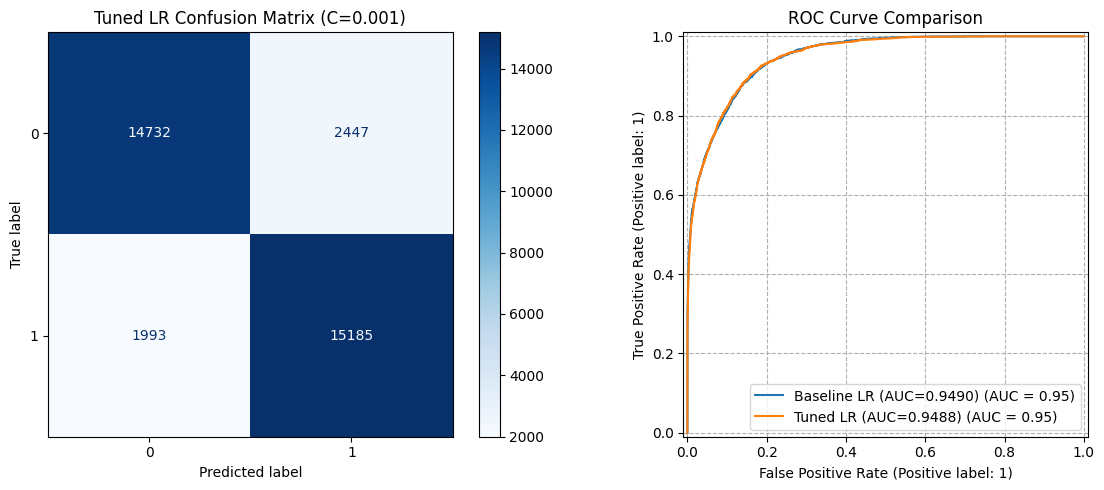

In [5]:
# --- Visualization: Confusion Matrix and ROC Curve ---

# 1. Confusion Matrix for the Tuned Model
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
ConfusionMatrixDisplay.from_estimator(
    tuned_pipeline,
    X_test,
    y_test,
    cmap=plt.cm.Blues,
    ax=plt.gca()
)
plt.title(f'Tuned LR Confusion Matrix (C={best_params["classifier__C"]:.3f})')
plt.grid(False)

# 2. ROC Curve Comparison
plt.subplot(1, 2, 2)
RocCurveDisplay.from_estimator(
    baseline_pipeline,
    X_test,
    y_test,
    name=f'Baseline LR (AUC={metrics_baseline["AUC"]:.4f})',
    ax=plt.gca()
)
RocCurveDisplay.from_estimator(
    tuned_pipeline,
    X_test,
    y_test,
    name=f'Tuned LR (AUC={metrics_tuned["AUC"]:.4f})',
    ax=plt.gca()
)

plt.title('ROC Curve Comparison')
plt.grid(linestyle='--')
plt.tight_layout()
plt.savefig('logistic_regression_evaluation_full_features.png')
print("\nEvaluation visualizations saved as 'logistic_regression_evaluation_full_features.png'")